<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>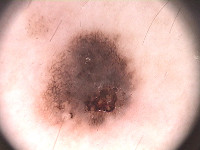</td><td>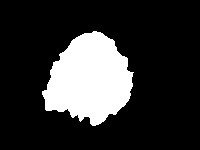</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [72]:
# !gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

In [73]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [74]:
images = []
lesions = []
from skimage.io import imread
import os

root = 'PH2Dataset/PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [75]:
from skimage.transform import resize

size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True, ) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [76]:
import numpy as np

X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

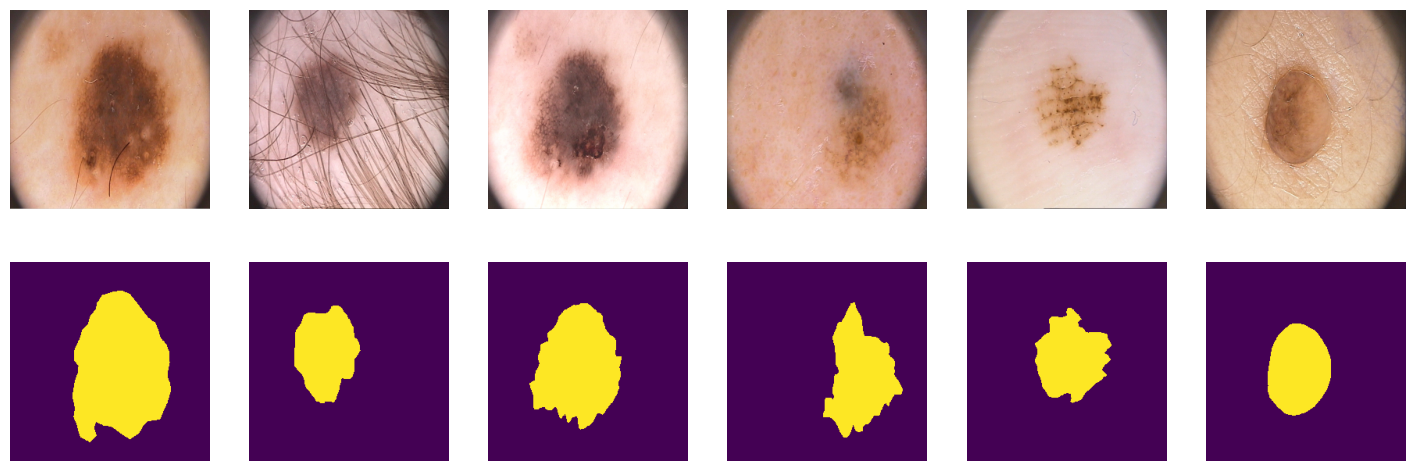

In [77]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i + 1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i + 7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [78]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [79]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [80]:
import torch
from torch.utils.data import DataLoader

batch_size = 6
_pin = torch.cuda.is_available()
train_dataloader = DataLoader(
    list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
    batch_size=batch_size, shuffle=True, pin_memory=_pin)
valid_dataloader = DataLoader(
    list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
    batch_size=batch_size, shuffle=False, pin_memory=_pin)
test_dataloader = DataLoader(
    list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
    batch_size=batch_size, shuffle=False, pin_memory=_pin)

In [81]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True
print('device:', device)

GPU: NVIDIA GeForce RTX 4060
device: cuda


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [ ]:
# !pip install torchmetrics


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:**

$$\log\sigma(\hat y) = \log\left(\frac{1}{1 + e^{-\hat y}}\right) = \log(1) - \log(1 + e^{-\hat y}) = -\log(1 + e^{-\hat y})$$

$$1 - \sigma(\hat y) = 1 - \frac{1}{1 + e^{-\hat y}} = \frac{1 + e^{-\hat y} - 1}{1 + e^{-\hat y}} = \frac{e^{-\hat y}}{1 + e^{-\hat y}}$$
$$\log(1 - \sigma(\hat y)) = \log(e^{-\hat y}) - \log(1 + e^{-\hat y}) = -\hat y - \log(1 + e^{-\hat y})$$

$$\mathcal L = - \left[ y \cdot (-\log(1 + e^{-\hat y})) + (1 - y) \cdot (-\hat y - \log(1 + e^{-\hat y})) \right]$$

$$\mathcal L = - \left[ -y\log(1 + e^{-\hat y}) - \hat y - \log(1 + e^{-\hat y}) + y\hat y + y\log(1 + e^{-\hat y}) \right]$$

$$\mathcal L = - \left[ -\hat y - \log(1 + e^{-\hat y}) + y\hat y \right]$$

$$\mathcal L = \hat y - y\hat y + \log(1 + e^{-\hat y})$$


### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [84]:
import torch.nn.functional as F
import torch.nn as nn

In [85]:
bce_torch = nn.BCELoss(reduction='sum')  # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [86]:
def bce_loss(y_pred, y_real):
    return -torch.sum(y_real * torch.log(torch.sigmoid(y_pred)) + (1 - y_real) * torch.log(1 - torch.sigmoid(y_pred)))


def bce_true(y_pred, y_real):
    return torch.sum(y_pred - y_real * y_pred + torch.log(1 + torch.exp(- y_pred)))

Проверим корректность работы на простом примере

In [87]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss             = 3.309825897216797
BCE loss честно посчитанный                = 3.309826135635376
BCE loss from torch bce_torch              = 3.309825897216797
BCE loss from torch with logits bce_torch  = 3.309825897216797


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [88]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [89]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 14.530338287353516
BCE loss честно посчитанный               = 14.530338287353516
BCE loss from torch bce_torch             = 14.530338287353516
BCE loss from torch with logits bce_torch = 14.530338287353516


In [90]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [91]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt


Retrieving folder contents
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: C:\Users\Professional\PycharmProjects\JupyterProject\for_asserts\labels.pt

  0%|          | 0.00/1.18k [00:00<?, ?B/s]
100%|██████████| 1.18k/1.18k [00:00<00:00, 2.24MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: C:\Users\Professional\PycharmProjects\JupyterProject\for_asserts\logits.pt

  0%|          | 0.00/1.18k [00:00<?, ?B/s]
100%|██████████| 1.18k/1.18k [00:00<?, ?B/s]
Download completed


In [92]:
path_to_dummy_samples = 'for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

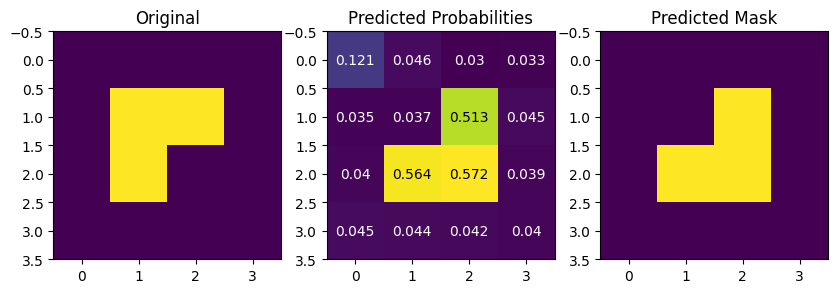

In [93]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3 * 10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j, i), label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i, j, round(label, 3), color=color, ha='center', va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [94]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(),
                                                    dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

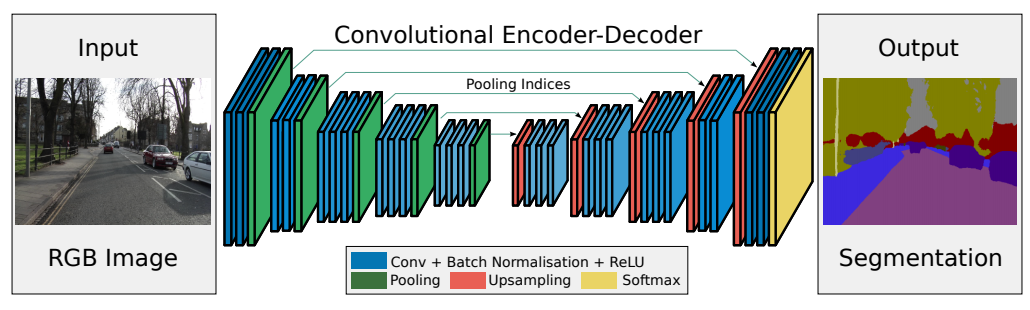

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [95]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams

rcParams['figure.figsize'] = (15, 4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [96]:
model_vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

In [97]:
model_vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [98]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1):
        super(EncoderBlock, self).__init__()  # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList()  # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, padding=padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth - 1):
            self.layers.append(nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=kernel_size,
                                         padding=padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2,
                                       return_indices=True)  #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [99]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1, is_last=False):
        super(DecoderBlock, self).__init__()  # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList()  # в self.layers будем добавлять слои блока

        # Unpooling
        self.unpooling = nn.MaxUnpool2d(kernel_size=2, stride=2)
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth - 1):
            self.layers.append(
                nn.Conv2d(in_channels=in_channels, out_channels=in_channels, kernel_size=kernel_size, padding=padding))
            self.layers.append(nn.BatchNorm2d(in_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.layers.append(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, padding=padding))
        if not is_last:
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

    def forward(self, x, indices):
        x = self.unpooling(x, indices)
        for layer in self.layers:
            x = layer(x)
        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [100]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, num_features=64) -> None:
        super(SegNet, self).__init__()

        # Encoder
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)
        self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2)
        self.encoder2 = EncoderBlock(num_features * 2, num_features * 4, depth=3)
        self.encoder3 = EncoderBlock(num_features * 4, num_features * 8, depth=3)

        # Encoder bottleneck - количество каналов на входе и на выходе одинаково
        self.encoder4 = EncoderBlock(num_features * 8, num_features * 8, depth=3)

        # Decoder bottleneck
        self.decoder0 = DecoderBlock(num_features * 8, num_features * 8, depth=3)

        # Decoder
        self.decoder1 = DecoderBlock(num_features * 8, num_features * 4, depth=3)
        self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth=3)
        self.decoder3 = DecoderBlock(num_features * 2, num_features, depth=2)
        self.decoder4 = DecoderBlock(num_features, out_channels, depth=2, is_last=True)

    def forward(self, x):
        # encoder
        x, indices0 = self.encoder0(x)
        x, indices1 = self.encoder1(x)
        x, indices2 = self.encoder2(x)
        x, indices3 = self.encoder3(x)
        x, indices4 = self.encoder4(x)

        # decoder
        x = self.decoder0(x, indices4)
        x = self.decoder1(x, indices3)
        x = self.decoder2(x, indices2)
        x = self.decoder3(x, indices1)

        output = self.decoder4(x, indices0)
        return output

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [101]:

from IPython.display import clear_output

# tqdm.auto: текстовый прогресс; tqdm.notebook часто «висит» в PyCharm/Windows без обновления батчей
from tqdm.auto import tqdm

In [102]:
def _iou_scalar(iou_tensor):
    """Одно число IoU из JaccardIndex (в т.ч. average='none')."""
    v = iou_tensor.float().mean() if iou_tensor.numel() > 0 else iou_tensor.float()
    return float(v.item())


def train_one_epoch(model, dataloader, criterion, optimizer, iou_metric):
    model.train()
    epoch_loss = 0.0
    iou_metric.reset()

    for x_batch, y_batch in tqdm(dataloader, desc="Training", leave=True):
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outp = model(x_batch)
        loss = criterion(outp, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        with torch.no_grad():
            probs = torch.sigmoid(outp)
            iou_metric.update(probs, y_batch.int())

    avg_loss = epoch_loss / len(dataloader)
    avg_iou = _iou_scalar(iou_metric.compute())
    return avg_loss, avg_iou


def eval_one_epoch(model, dataloader, criterion, iou_metric):
    model.eval()
    epoch_loss = 0.0
    iou_metric.reset()

    with torch.no_grad():
        for x_batch, y_batch in tqdm(dataloader, desc="Validation", leave=True):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outp = model(x_batch)
            loss = criterion(outp, y_batch)
            epoch_loss += loss.item()
            probs = torch.sigmoid(outp)
            iou_metric.update(probs, y_batch.int())

    avg_loss = epoch_loss / len(dataloader)
    avg_iou = _iou_scalar(iou_metric.compute())
    return avg_loss, avg_iou


def train_model(model, loaders, criterion, optimizer, num_epochs, iou_metric=iou_score):
    history = {
        'train_loss': [], 'val_loss': [],
        'train_metrics': [], 'val_metrics': [],
    }
    best_val_iou = -1.0

    for epoch in range(num_epochs):
        train_loss, train_iou = train_one_epoch(
            model, loaders['train'], criterion, optimizer, iou_metric)
        val_loss, val_iou = eval_one_epoch(
            model, loaders['val'], criterion, iou_metric)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_metrics'].append(train_iou)
        history['val_metrics'].append(val_iou)

        clear_output(wait=True)

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"--- Model saved! (best val IoU: {val_iou:.4f}) ---")

        fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))
        ax0.plot(history['train_metrics'], label='Train IoU', marker='.')
        ax0.plot(history['val_metrics'], label='Val IoU', marker='.')
        ax0.set_title('IoU (Jaccard)')
        ax0.set_xlabel('Epoch')
        ax0.set_ylabel('IoU')
        ax0.legend()
        ax0.set_ylim(0.0, 1.0)

        ax1.plot(history['train_loss'], label='Train Loss')
        ax1.plot(history['val_loss'], label='Validation Loss')
        ax1.set_title('Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        fig.suptitle(f"Epoch {epoch + 1}/{num_epochs}")
        plt.tight_layout()
        plt.show()

        print(f"Epoch {epoch + 1}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f} | "
              f"Train IoU: {train_iou:.4f}, Val IoU: {val_iou:.4f}")

    return history

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

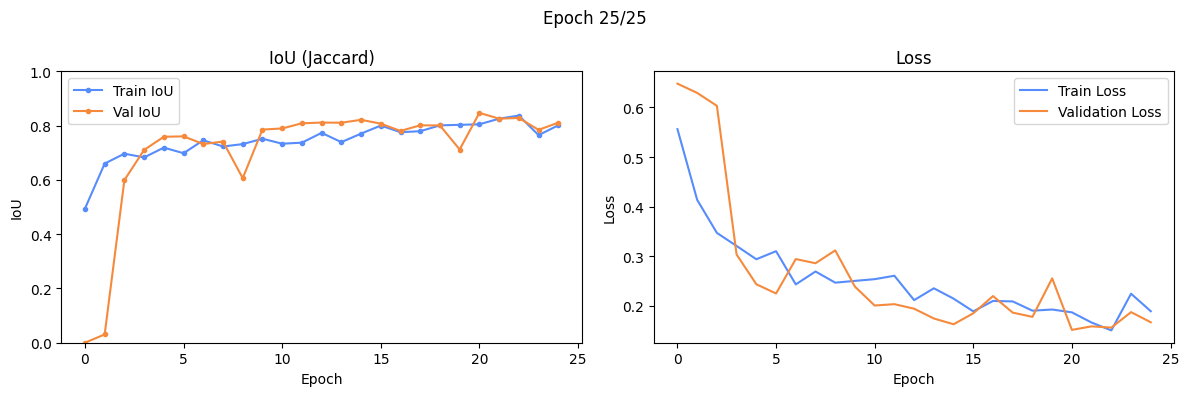

Epoch 25/25
Train Loss: 0.1894, Val Loss: 0.1671 | Train IoU: 0.8011, Val IoU: 0.8108


In [103]:
loaders = {
    'train': train_dataloader,
    'val': valid_dataloader,
    'test': test_dataloader
}
model = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
history = train_model(model, loaders, criterion, optimizer, num_epochs=25)

In [104]:
print(history)

{'train_loss': [0.5563695220386281, 0.413870608105379, 0.34721682352178235, 0.3208928265992333, 0.2941389890278087, 0.31037743564914255, 0.24346002235132105, 0.2694212566403782, 0.2469355376327739, 0.2505425819579293, 0.25397864772992973, 0.26087006575921, 0.2117221250253565, 0.23558808687855215, 0.21474782070692847, 0.1891092079527238, 0.21005640398053563, 0.20913835658746607, 0.19047119819066105, 0.19282209873199463, 0.18711593659485087, 0.16652936619870803, 0.1507666338892544, 0.2246718200690606, 0.18938043625915751], 'val_loss': [0.6479694975747002, 0.6293904417090945, 0.6033249629868401, 0.3036246879233254, 0.24374523593319786, 0.22516234384642708, 0.294503981868426, 0.2861061990261078, 0.311956192056338, 0.23888485464784834, 0.20086564289198983, 0.20360088182820213, 0.19444641636477578, 0.17475934575001398, 0.16310658471451867, 0.18517463157574335, 0.21992729604244232, 0.18653884943988588, 0.17804722819063398, 0.2556250501010153, 0.1517755405770408, 0.15890555414888594, 0.1563579

## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [105]:
def test(model, test_loader, criterion, iou_metric=iou_score, checkpoint_path='best_model.pth'):
    state = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state)
    model.to(device)
    test_loss, test_iou = eval_one_epoch(model, test_loader, criterion, iou_metric)
    print(f"Test | Loss: {test_loss:.4f}, IoU: {test_iou:.4f}")

In [106]:
test(model, test_dataloader, criterion)

Validation:   0%|          | 0/9 [00:00<?, ?it/s]

Test | Loss: 0.1491, IoU: 0.8343


# Задания: Мир других лоссов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [107]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [108]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    dims = tuple(range(1, logits.ndimension()))
    pred = logits.sigmoid() > threshold
    tp = (pred & labels.bool()).sum(dims).float()
    fp = (pred & ~labels.bool()).sum(dims).float()
    fn = (~pred & labels.bool()).sum(dims).float()
    score = (2 * tp + 1e-8) / (2 * tp + fp + fn + 1e-8)
    return score.mean()

Проверим на корректность функцию dice_score:

In [109]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro').to(device)
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

C:\Users\Professional\PycharmProjects\JupyterProject\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


tensor(0.3158, device='cuda:0')

In [110]:
dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.6667, device='cuda:0')

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [111]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):
    dims = tuple(range(1, logits.ndimension()))
    pred = logits.sigmoid()
    tp = (pred * labels.bool()).sum(dims).float()
    fp = (pred * ~labels.bool()).sum(dims).float()
    fn = ((1 - pred) * labels.bool()).sum(dims).float()
    score = (2 * tp + 1e-8) / (2 * tp + fp + fn + 1e-8)
    loss = 1 - score.mean()
    return loss

Проверка на корректность:

In [112]:
# проверьте, что у вас установлена библиотека
# !pip install segmentation-models-pytorch

In [113]:
from segmentation_models_pytorch.losses import DiceLoss

dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [114]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'],
                                                                                              dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проверка корректности функции:

In [118]:
from torchvision.ops import sigmoid_focal_loss

sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161, device='cuda:0')

In [119]:
focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], gamma=2.0)

tensor(3.6161, device='cuda:0')

In [120]:
assert sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2,
                          reduction='sum') == focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], gamma=2.0)

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



In [121]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):
    dims = tuple(range(1, logits.ndimension()))
    pred = logits.sigmoid()
    tp = (pred * labels.bool()).sum(dims).float()
    fp = (pred * ~labels.bool()).sum(dims).float()
    fn = ((1 - pred) * labels.bool()).sum(dims).float()
    score = (2 * tp + 1e-8) / (2 * tp + fp + fn + 1e-8)
    loss = 1 - score.mean()
    return loss

In [122]:
def focal_loss(y_pred, y_real, gamma=2):
    p_t = y_pred.sigmoid() * y_real + (1 - y_pred.sigmoid()) * (1 - y_real)
    bce = F.binary_cross_entropy_with_logits(y_pred, y_real.float(), reduction='none')
    loss = ((1 - p_t) ** gamma * bce)
    return loss.mean()

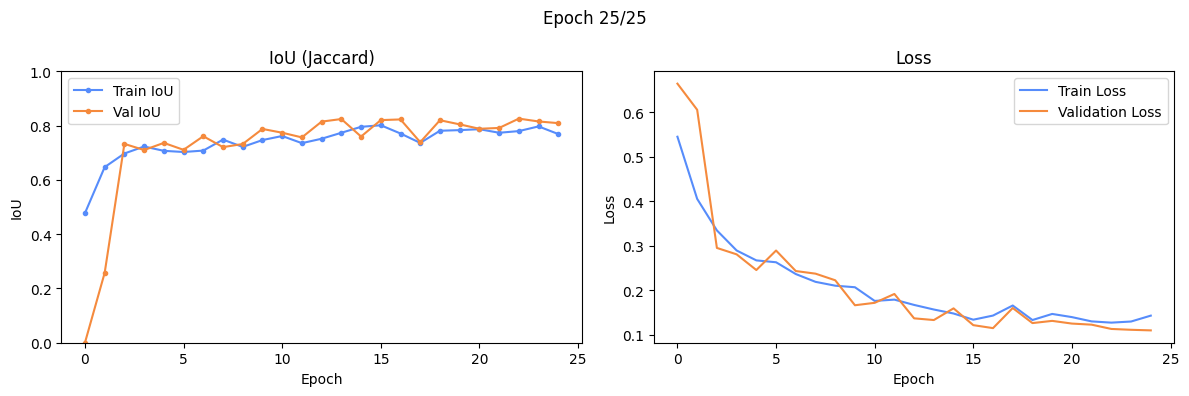

Epoch 25/25
Train Loss: 0.1425, Val Loss: 0.1093 | Train IoU: 0.7689, Val IoU: 0.8091


In [123]:
model = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

history_dice = train_model(model, loaders, dice_loss, optimizer, num_epochs=25)

In [124]:
test(model, test_dataloader, dice_loss)

Validation:   0%|          | 0/9 [00:00<?, ?it/s]

Test | Loss: 0.1331, IoU: 0.7916


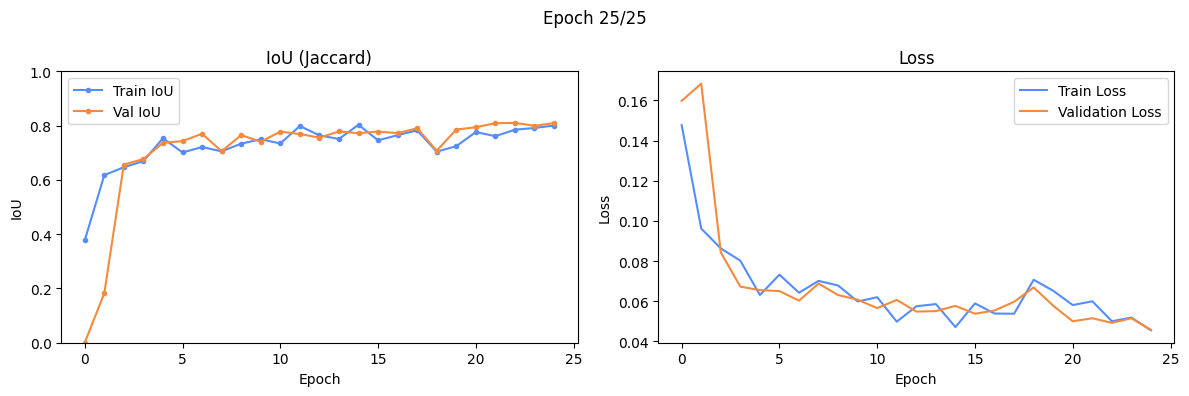

Epoch 25/25
Train Loss: 0.0455, Val Loss: 0.0458 | Train IoU: 0.8004, Val IoU: 0.8094


In [125]:
model = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

history_focal = train_model(model, loaders, focal_loss, optimizer, num_epochs=25)

In [126]:
test(model, test_dataloader, focal_loss)

Validation:   0%|          | 0/9 [00:00<?, ?it/s]

Test | Loss: 0.0442, IoU: 0.8129


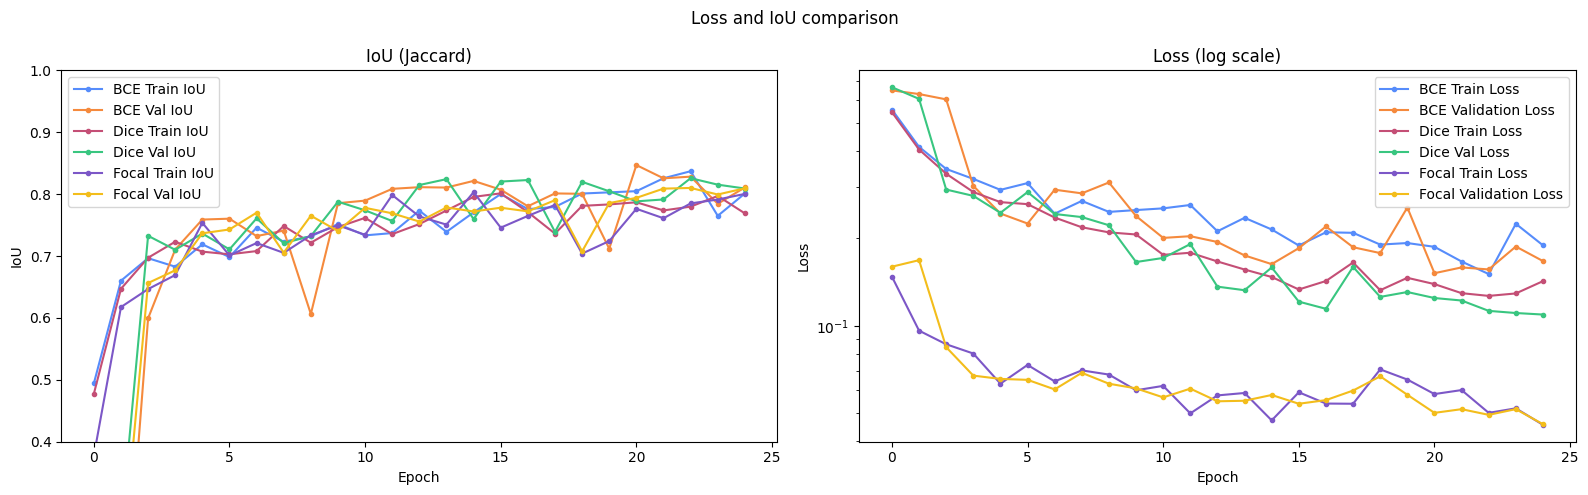

In [127]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 5))
ax0.plot(history['train_metrics'], label='BCE Train IoU', marker='.')
ax0.plot(history['val_metrics'], label='BCE Val IoU', marker='.')
ax0.plot(history_dice['train_metrics'], label='Dice Train IoU', marker='.')
ax0.plot(history_dice['val_metrics'], label='Dice Val IoU', marker='.')
ax0.plot(history_focal['train_metrics'], label='Focal Train IoU', marker='.')
ax0.plot(history_focal['val_metrics'], label='Focal Val IoU', marker='.')
ax0.set_title('IoU (Jaccard)')
ax0.set_xlabel('Epoch')
ax0.set_ylabel('IoU')
ax0.legend()
ax0.set_ylim(0.4, 1.0)
ax1.plot(history['train_loss'], label='BCE Train Loss', marker='.')
ax1.plot(history['val_loss'], label='BCE Validation Loss', marker='.')
ax1.plot(history_dice['train_loss'], label='Dice Train Loss', marker='.')
ax1.plot(history_dice['val_loss'], label='Dice Val Loss', marker='.')
ax1.plot(history_focal['train_loss'], label='Focal Train Loss', marker='.')
ax1.plot(history_focal['val_loss'], label='Focal Validation Loss', marker='.')
ax1.set_yscale('log')
ax1.set_title('Loss (log scale)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
fig.suptitle(f"Loss and IoU comparison")
plt.tight_layout()
plt.show()

# Ответ на вопросы:
По графикам сложно однозначно сказать о сходимости, все модели сходятся примерно одинаково. Проблема с Focal Loss в том, что она имеет другой маштаб. Но по итогу, все модели всё равно ведут себя примерно одинаково по loss - средне плавно спускаясь вниз. При этом по метрике у всех моделей наблюдаются скачки, но у Focal Loss они более стабильные, а у BCE и Dice Loss более резкие. В целом, по метрике BCE в моменте на тесте стала лучше, но потом в итоге Dice и Focal сравнялись и стали выше BCE, при этом не превысив тот максимум BCE. Действительные выводы сложно делать в условиях достаточно малого размера датасета и числа эпох.

 # Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

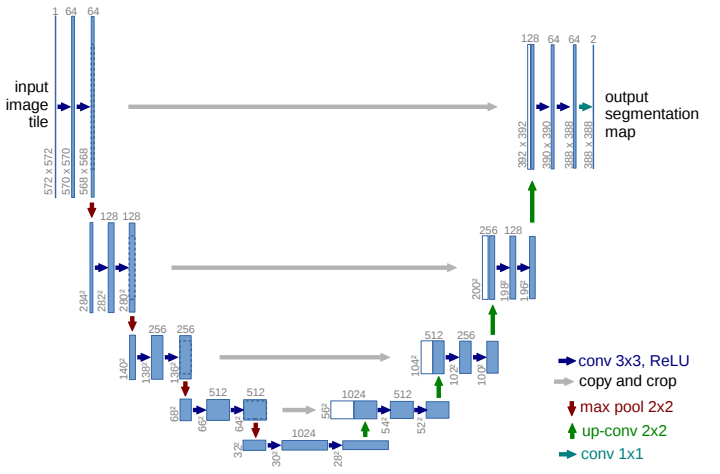

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [128]:
import torch.nn.functional as F
import torch.nn as nn

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

In [129]:
import torch
import torch.nn as nn


class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth=2, kernel_size=3, padding=1):
        super(EncoderBlock, self).__init__()
        self.layers = nn.ModuleList()

        self.layers.append(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, padding=padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        for i in range(depth - 1):
            self.layers.append(nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=kernel_size,
                                         padding=padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)

        skip_connection = x

        x = self.maxpooling(x)
        return x, skip_connection


class BottleneckBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth=2, kernel_size=3, padding=1):
        super(BottleneckBlock, self).__init__()
        self.layers = nn.ModuleList()

        self.layers.append(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, padding=padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        for i in range(depth - 1):
            self.layers.append(nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=kernel_size,
                                         padding=padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth=2, kernel_size=3, padding=1):
        super(DecoderBlock, self).__init__()
        self.layers = nn.ModuleList()

        self.upconv = nn.ConvTranspose2d(in_channels=in_channels, out_channels=out_channels, kernel_size=2, stride=2)

        conv_in_channels = out_channels * 2

        self.layers.append(
            nn.Conv2d(in_channels=conv_in_channels, out_channels=out_channels, kernel_size=kernel_size,
                      padding=padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        for i in range(depth - 1):
            self.layers.append(
                nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=kernel_size,
                          padding=padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

    def forward(self, x, skip_connection):
        x = self.upconv(x)

        x = torch.cat([skip_connection, x], dim=1)

        for layer in self.layers:
            x = layer(x)
        return x


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=2, num_features=64):
        super(UNet, self).__init__()

        self.encoder1 = EncoderBlock(in_channels, num_features, depth=2)
        self.encoder2 = EncoderBlock(num_features, num_features * 2, depth=2)
        self.encoder3 = EncoderBlock(num_features * 2, num_features * 4, depth=2)
        self.encoder4 = EncoderBlock(num_features * 4, num_features * 8, depth=2)

        self.bottleneck = BottleneckBlock(num_features * 8, num_features * 16, depth=2)

        self.decoder4 = DecoderBlock(num_features * 16, num_features * 8, depth=2)
        self.decoder3 = DecoderBlock(num_features * 8, num_features * 4, depth=2)
        self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth=2)
        self.decoder1 = DecoderBlock(num_features * 2, num_features, depth=2)

        self.final_conv = nn.Conv2d(in_channels=num_features, out_channels=out_channels, kernel_size=1)

    def forward(self, x):
        x, skip1 = self.encoder1(x)
        x, skip2 = self.encoder2(x)
        x, skip3 = self.encoder3(x)
        x, skip4 = self.encoder4(x)

        x = self.bottleneck(x)

        x = self.decoder4(x, skip4)
        x = self.decoder3(x, skip3)
        x = self.decoder2(x, skip2)
        x = self.decoder1(x, skip1)

        output = self.final_conv(x)
        return output

In [130]:
unet_model = UNet().to(device)

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



--- Model saved! (best val IoU: 0.8479) ---


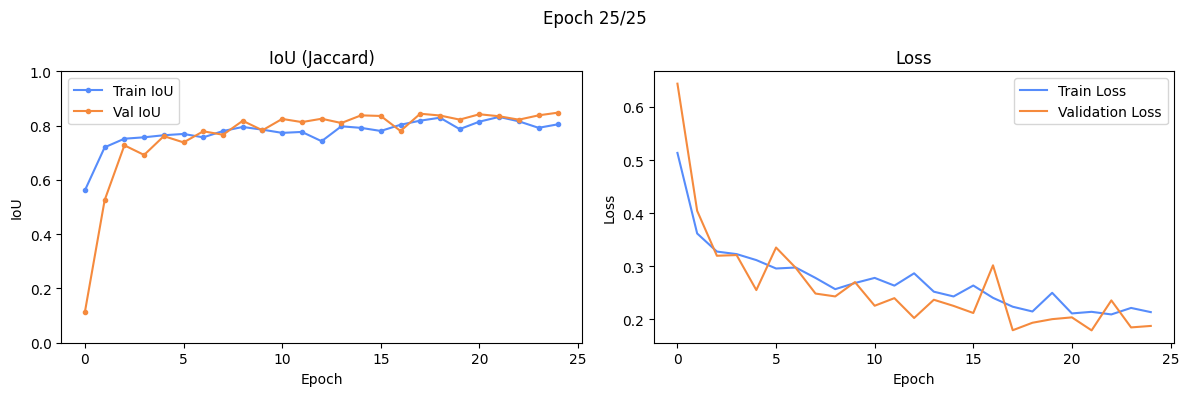

Epoch 25/25
Train Loss: 0.2138, Val Loss: 0.1878 | Train IoU: 0.8050, Val IoU: 0.8479


In [131]:
model = UNet(in_channels=3, out_channels=1, num_features=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

history_bce = train_model(model, loaders, bce_loss, optimizer, num_epochs=25)

In [132]:
test(model, test_dataloader, bce_loss)

Validation:   0%|          | 0/9 [00:00<?, ?it/s]

Test | Loss: 0.1708, IoU: 0.8444


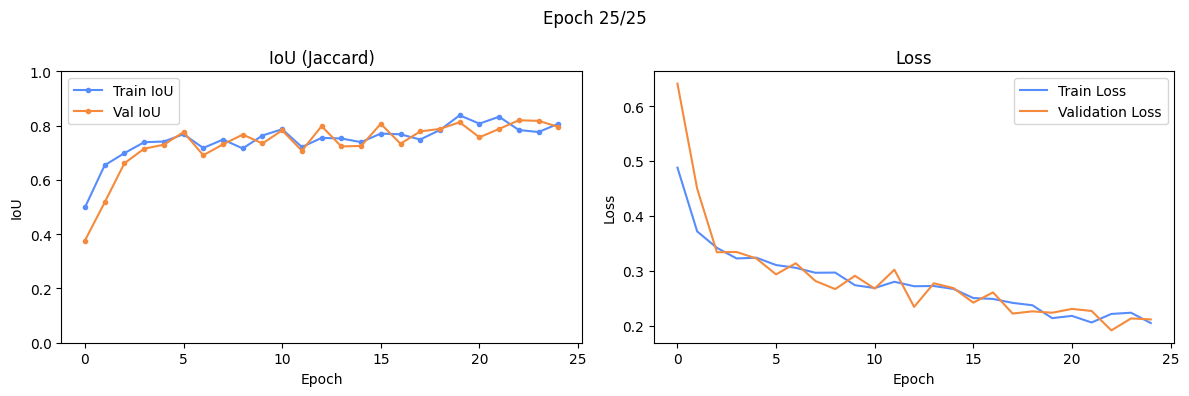

Epoch 25/25
Train Loss: 0.2048, Val Loss: 0.2115 | Train IoU: 0.8070, Val IoU: 0.7954


In [133]:
model = UNet(in_channels=3, out_channels=1, num_features=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

history_dice = train_model(model, loaders, dice_loss, optimizer, num_epochs=25)

In [134]:
test(model, test_dataloader, dice_loss)

Validation:   0%|          | 0/9 [00:00<?, ?it/s]

Test | Loss: 0.1900, IoU: 0.8448


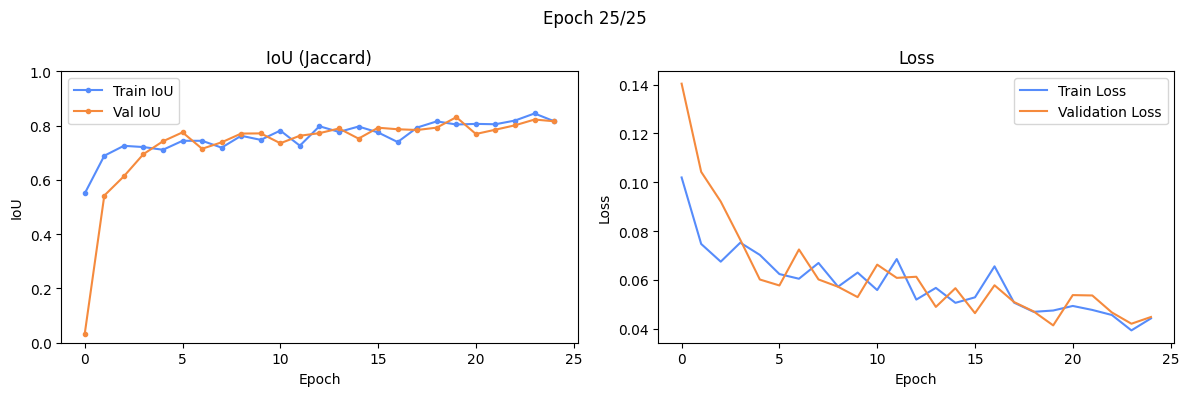

Epoch 25/25
Train Loss: 0.0443, Val Loss: 0.0448 | Train IoU: 0.8161, Val IoU: 0.8160


In [135]:
model = UNet(in_channels=3, out_channels=1, num_features=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

history_focal = train_model(model, loaders, focal_loss, optimizer, num_epochs=25)

In [136]:
test(model, test_dataloader, focal_loss)

Validation:   0%|          | 0/9 [00:00<?, ?it/s]

Test | Loss: 0.0378, IoU: 0.8245


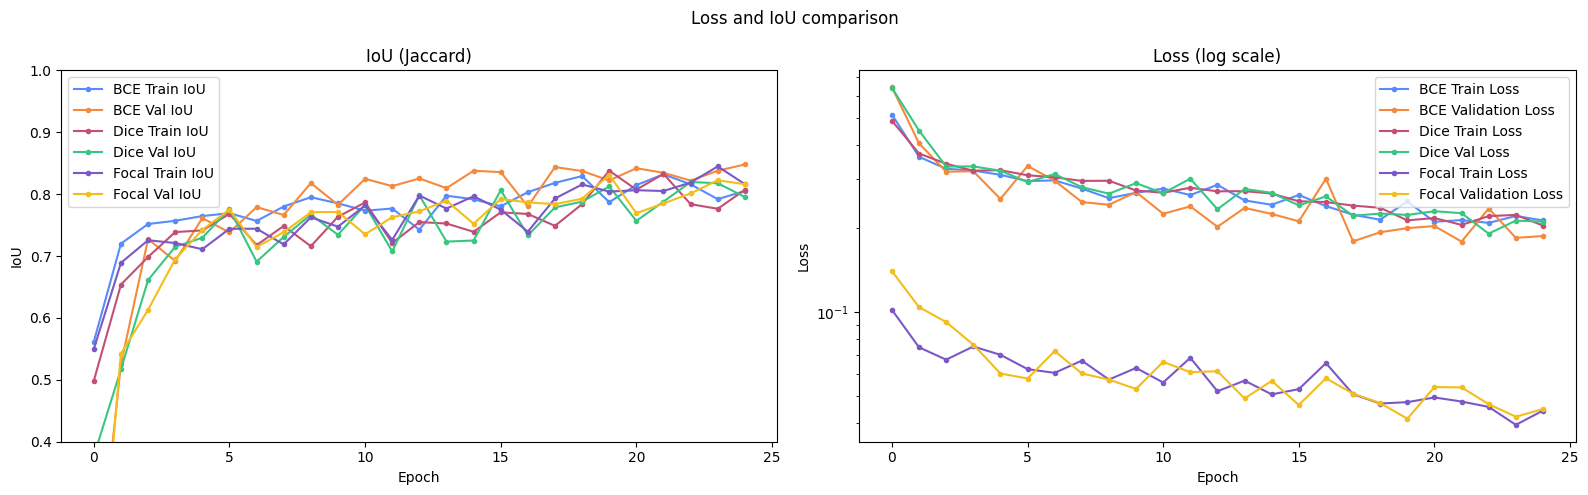

In [137]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 5))
ax0.plot(history_bce['train_metrics'], label='BCE Train IoU', marker='.')
ax0.plot(history_bce['val_metrics'], label='BCE Val IoU', marker='.')
ax0.plot(history_dice['train_metrics'], label='Dice Train IoU', marker='.')
ax0.plot(history_dice['val_metrics'], label='Dice Val IoU', marker='.')
ax0.plot(history_focal['train_metrics'], label='Focal Train IoU', marker='.')
ax0.plot(history_focal['val_metrics'], label='Focal Val IoU', marker='.')
ax0.set_title('IoU (Jaccard)')
ax0.set_xlabel('Epoch')
ax0.set_ylabel('IoU')
ax0.legend()
ax0.set_ylim(0.4, 1.0)
ax1.plot(history_bce['train_loss'], label='BCE Train Loss', marker='.')
ax1.plot(history_bce['val_loss'], label='BCE Validation Loss', marker='.')
ax1.plot(history_dice['train_loss'], label='Dice Train Loss', marker='.')
ax1.plot(history_dice['val_loss'], label='Dice Val Loss', marker='.')
ax1.plot(history_focal['train_loss'], label='Focal Train Loss', marker='.')
ax1.plot(history_focal['val_loss'], label='Focal Validation Loss', marker='.')
ax1.set_yscale('log')
ax1.set_title('Loss (log scale)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
fig.suptitle(f"Loss and IoU comparison")
plt.tight_layout()
plt.show()

Лучшая метрика - BCE.

Лучший лосс - Focal, но маштаб разный.

Модели обучаются одинаково быстро - если судить по изменению лосса.

UNet дал большую метрику - по этому признаку лучше.
